# MindRL + HSSM: hierarchical RW–LBA4 choice and response time

This notebook extends the choice-only MindRL tutorial to a joint
model of which bandit arm a participant chooses and how long that
decision takes. It uses the same 25 participants, trajectories, and
train/held-out split as the choice-only notebook.

By the end, you will be able to:

1. connect Rescorla–Wagner values to four LBA accumulators;
2. register a differentiable joint choice/RT decision process;
3. define participant variation with hierarchical HSSM formulas;
4. fit an RLSSM with HSSM's variational-inference API; and
5. check choice and RT predictions on train and held-out episodes.

The two supplied trial CSVs are the model inputs. No reward schedule
or machine-specific path is needed.

## 1. Orientation and API ownership

| Layer | Responsibility in this notebook |
| --- | --- |
| **ssms** | Task Environment, Learning Process, Decision Process, `ModelConfig`, and the chronological RL scan |
| **HSSM** | `RLSSMConfig` bridge, formulas, priors, participant hierarchy, `RLSSM`, and inference |
| **Notebook support** | Exact LBA4 density registration, stable VI starts, posterior extraction, observed-history PPC simulation, and plotting |

The visible cells teach the cognitive model and HSSM API. The long
numerical implementation is collected in one expandable support
cell so it remains available without dominating the reading path.

### Setup

Rewards are already scaled to 0–1, RTs are represented in seconds,
and every setting below is fixed for reproducibility. The executed
notebook uses a demonstration-scale ADVI fit rather than claiming a
production-quality posterior.

In [1]:
import hssm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import ssms.rl as rl

hssm.set_floatX("float32", update_jax=True)

SEED = 20260707
N_ACTIONS = 4
INITIAL_Q = 1.0
FIXED_BETA = 100.0
FIXED_T0 = 0.100
DRIFT_SD = 0.1
N_VI_ITER = 10_000
N_POSTERIOR_DRAWS = 1_000
N_PPC_DRAWS = 100
VI_LEARNING_RATE = 0.001
VI_START_SIGMA = 0.01

Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


### Implementation support — collapsed by default

This cell contains the exact JAX LBA4 density and sampler, one-time
registry wiring, data and posterior bookkeeping, stable VI starts,
observed-history PPC simulation, and plotting. These details are
important for reproducibility, but they are not required to follow
how ssms and HSSM define and fit the cognitive model.

In [2]:
from pathlib import Path

import jax
import jax.numpy as jnp
from hssm.utils import annotate_function
from jax import lax, random
from jax.scipy.special import ndtr


DATA_DIR = Path("data")
FIT_COLS = [
    "participant_id",
    "response",
    "feedback",
    "episode_start",
    "rt",
    "trial_mask",
]
PARAMETER_NAMES = ("rl_alpha", "epsilon", "scaler", "A", "B")
PARAMETER_BOUNDS = {
    "rl_alpha": (0.01, 1.0),
    "epsilon": (0.001, 0.5),
    "scaler": (0.001, 10.0),
    "A": (0.001, 1.0),
    "B": (0.001, 1.0),
}
PRIOR_CENTERS = {
    "rl_alpha": 0.6,
    "epsilon": 0.1,
    "scaler": 0.5,
    "A": 0.3,
    "B": 0.2,
}
PRIOR_SCALES = {
    "rl_alpha": 0.25,
    "epsilon": 0.08,
    "scaler": 0.5,
    "A": 0.15,
    "B": 0.1,
}
LBA_COLUMNS = (
    "A",
    "B",
    "v0",
    "v1",
    "v2",
    "v3",
    "t0",
    "rt",
    "response",
    "trial_mask",
)


def _normpdf(value):
    return jnp.exp(-0.5 * value**2) / jnp.sqrt(2.0 * jnp.pi)


def _tpdf(decision_time, A, threshold, drift):
    g = (threshold - A - decision_time * drift) / (decision_time * DRIFT_SD)
    h = (threshold - decision_time * drift) / (decision_time * DRIFT_SD)
    return (
        -drift * ndtr(g)
        + DRIFT_SD * _normpdf(g)
        + drift * ndtr(h)
        - DRIFT_SD * _normpdf(h)
    ) / A


def _tcdf(decision_time, A, threshold, drift):
    g = (threshold - A - decision_time * drift) / (decision_time * DRIFT_SD)
    h = (threshold - decision_time * drift) / (decision_time * DRIFT_SD)
    return (
        1.0
        + ((threshold - A - decision_time * drift) / A) * ndtr(g)
        - ((threshold - decision_time * drift) / A) * ndtr(h)
        + ((decision_time * DRIFT_SD) / A) * _normpdf(g)
        - ((decision_time * DRIFT_SD) / A) * _normpdf(h)
    )


def lba4_jax_masked_logp(lan_matrix):
    matrix = jnp.asarray(lan_matrix)
    A, B, v0, v1, v2, v3, t0, rt, response, trial_mask = matrix.T
    included = trial_mask == 1
    safe_rt = jnp.where(included, rt, t0 + 1.0)
    safe_response = jnp.where(included, response, 0).astype(jnp.int32)
    decision_time = safe_rt - t0
    threshold = A + B
    drifts = jnp.stack([v0, v1, v2, v3], axis=-1)
    densities = jnp.stack(
        [_tpdf(decision_time, A, threshold, drift) for drift in drifts.T],
        axis=-1,
    )
    survivors = 1.0 - jnp.stack(
        [_tcdf(decision_time, A, threshold, drift) for drift in drifts.T],
        axis=-1,
    )
    d0, d1, d2, d3 = densities.T
    s0, s1, s2, s3 = survivors.T
    likelihoods = jnp.stack(
        [
            d0 * s1 * s2 * s3,
            s0 * d1 * s2 * s3,
            s0 * s1 * d2 * s3,
            s0 * s1 * s2 * d3,
        ],
        axis=-1,
    )
    selected = jnp.take_along_axis(
        likelihoods, safe_response[:, None], axis=-1
    )[:, 0]
    all_negative = jnp.prod(ndtr(-drifts / DRIFT_SD), axis=-1)
    density = selected / (1.0 - all_negative)
    logp = jnp.log(jnp.clip(density, jnp.exp(-66.1), jnp.exp(66.1)))
    return jnp.where(included, logp, jnp.zeros_like(logp))


def simulate_lba4(key, *, A, B, v0, v1, v2, v3, t0):
    A = jnp.asarray(A)
    threshold = A + jnp.asarray(B)
    means = jnp.asarray([v0, v1, v2, v3])
    initial_key, redraw_key, start_key = random.split(key, 3)

    def draw_drifts(draw_key):
        return means + DRIFT_SD * random.normal(draw_key, shape=(4,))

    def needs_redraw(state):
        return jnp.all(state[1] <= 0.0)

    def redraw(state):
        next_key, sample_key = random.split(state[0])
        return next_key, draw_drifts(sample_key)

    initial = draw_drifts(initial_key)
    _, drifts = lax.while_loop(needs_redraw, redraw, (redraw_key, initial))
    starts = A * random.uniform(start_key, shape=(4,))
    finishing = jnp.where(drifts > 0.0, (threshold - starts) / drifts, jnp.inf)
    response = jnp.argmin(finishing).astype(jnp.int32)
    return jnp.asarray(t0) + jnp.min(finishing), response


@annotate_function(inputs=list(LBA_COLUMNS), outputs=["logp"])
def _annotated_lba4_logp(lan_matrix):
    return lba4_jax_masked_logp(lan_matrix)


def register_lba4_decision_process():
    from hssm.rl import registry as hssm_registry
    from ssms.config import get_model_registry, register_model_config

    decision_name = "lba4_jax_masked"
    params = ["A", "B", "v0", "v1", "v2", "v3", "t0"]
    bounds = {
        "A": (0.001, 1.0),
        "B": (0.001, 1.0),
        "v0": (0.0, 10.0),
        "v1": (0.0, 10.0),
        "v2": (0.0, 10.0),
        "v3": (0.0, 10.0),
        "t0": (0.005, 0.150),
    }
    defaults = [0.3, 0.2, 0.5, 0.5, 0.5, 0.5, FIXED_T0]
    ssms_registry = get_model_registry()
    if not ssms_registry.has_model(decision_name):
        register_model_config(
            decision_name,
            {
                "name": decision_name,
                "params": params,
                "param_bounds": [
                    [bounds[name][0] for name in params],
                    [bounds[name][1] for name in params],
                ],
                "n_params": len(params),
                "default_params": defaults,
                "nchoices": N_ACTIONS,
                "choices": list(range(N_ACTIONS)),
                "n_particles": N_ACTIONS,
                "simulator": simulate_lba4,
            },
        )
    if decision_name not in hssm_registry._SSM_REGISTRY:
        hssm.rl.register_ssm(
            decision_name,
            _annotated_lba4_logp,
            list_params_ssm=params,
            bounds_ssm=bounds,
            params_default_ssm=defaults,
            response=["rt", "response"],
        )


def load_joint_data():
    train = pd.read_csv(DATA_DIR / "train_trials.csv")
    heldout = pd.read_csv(DATA_DIR / "heldout_trials.csv")
    subjects = sorted(train["participant_id"].unique())
    assert subjects == sorted(heldout["participant_id"].unique())
    assert len(subjects) == 25
    return train, heldout, subjects


def mask_audit(train, heldout):
    rows = []
    for split, frame in (("train", train), ("heldout", heldout)):
        counts = frame["masking_reason"].value_counts()
        rows.append(
            {
                "split": split,
                "rows": len(frame),
                "included": int(counts.get("included", 0)),
                "missing": int(counts.get("missing", 0)),
                "at_or_below_100_ms": int(counts.get("below_100_ms", 0)),
                "above_3000_ms": int(counts.get("above_3000_ms", 0)),
            }
        )
    return pd.DataFrame(rows).set_index("split")


def _eta_prior(parameter):
    lower, upper = PARAMETER_BOUNDS[parameter]
    center = PRIOR_CENTERS[parameter]
    scale = PRIOR_SCALES[parameter]
    probability = (center - lower) / (upper - lower)
    derivative = (upper - lower) * probability * (1.0 - probability)
    return hssm.Prior(
        "Normal",
        mu=float(np.log(probability / (1.0 - probability))),
        sigma=float(scale / derivative),
    )


def _random_effect_prior():
    return {
        "name": "Normal",
        "mu": 0.0,
        "sigma": {"name": "HalfNormal", "sigma": 0.5},
    }


def _natural_to_eta(value, bounds):
    lower, upper = bounds
    probability = (float(value) - lower) / (upper - lower)
    return np.asarray(np.log(probability / (1.0 - probability)), dtype="float32")


def make_vi_start(model):
    start = model.pymc_model.initial_point(random_seed=SEED)
    for parameter in PARAMETER_NAMES:
        intercept_name = f"{parameter}_Intercept"
        if intercept_name in start:
            start[intercept_name] = _natural_to_eta(
                PRIOR_CENTERS[parameter], PARAMETER_BOUNDS[parameter]
            )
        sigma_name = f"{parameter}_1|participant_id_sigma_log__"
        if sigma_name in start:
            start[sigma_name] = np.asarray(np.log(0.15), dtype="float32")
        offset_name = f"{parameter}_1|participant_id_offset"
        if offset_name in start:
            start[offset_name] = np.zeros_like(start[offset_name], dtype="float32")
    return start


def make_start_sigma(start):
    return {
        name: np.full_like(np.asarray(value), VI_START_SIGMA, dtype="float32")
        for name, value in start.items()
    }


def _posterior_dataset(idata):
    posterior = idata.posterior
    return posterior.to_dataset() if hasattr(posterior, "to_dataset") else posterior


def _inverse_link(values, parameter):
    lower, upper = PARAMETER_BOUNDS[parameter]
    probability = 1.0 / (1.0 + np.exp(-np.asarray(values, dtype=float)))
    return lower + (upper - lower) * probability


def extract_parameter_summary(idata):
    posterior = _posterior_dataset(idata)
    rows = []
    participant_draws = {}
    for parameter in PARAMETER_NAMES:
        intercept = np.asarray(posterior[f"{parameter}_Intercept"], dtype=float)
        group = _inverse_link(intercept.reshape(-1), parameter)
        effect = posterior[f"{parameter}_1|participant_id"]
        effect_values = np.asarray(effect, dtype=float)
        values = _inverse_link(intercept[..., None] + effect_values, parameter)
        factor_dim = effect.dims[-1]
        labels = [str(value) for value in effect.coords[factor_dim].values]
        participant_draws[parameter] = {
            label: values[..., index].reshape(-1)
            for index, label in enumerate(labels)
        }
        rows.append(
            {
                "parameter": parameter,
                "population_median": float(np.median(group)),
                "population_hdi_3%": float(np.quantile(group, 0.03)),
                "population_hdi_97%": float(np.quantile(group, 0.97)),
                "participant_mean_min": float(
                    min(np.mean(draws) for draws in participant_draws[parameter].values())
                ),
                "participant_mean_max": float(
                    max(np.mean(draws) for draws in participant_draws[parameter].values())
                ),
            }
        )
    return pd.DataFrame(rows).set_index("parameter"), participant_draws


def plot_parameter_summary(summary, participant_draws):
    fig, axes = plt.subplots(1, len(PARAMETER_NAMES), figsize=(15, 3.2))
    for ax, parameter in zip(axes, PARAMETER_NAMES):
        means = [np.mean(value) for value in participant_draws[parameter].values()]
        row = summary.loc[parameter]
        ax.scatter(np.arange(len(means)), means, s=16, alpha=0.7)
        ax.axhline(row["population_median"], color="black", lw=1.5)
        ax.axhspan(
            row["population_hdi_3%"],
            row["population_hdi_97%"],
            color="black",
            alpha=0.12,
        )
        ax.set_title(parameter)
        ax.set_xlabel("participant")
    axes[0].set_ylabel("natural-scale value")
    fig.suptitle("Participant posterior means and population center")
    fig.tight_layout()
    return fig


def _participant_posterior_draws(idata, subjects, n_draws):
    posterior = _posterior_dataset(idata)
    total = int(posterior.sizes["chain"] * posterior.sizes["draw"])
    indices = np.sort(
        np.random.default_rng(SEED).choice(total, size=min(n_draws, total), replace=False)
    )
    result = []
    by_parameter = {}
    for parameter in PARAMETER_NAMES:
        intercept = np.asarray(posterior[f"{parameter}_Intercept"], dtype=float)
        effect = posterior[f"{parameter}_1|participant_id"]
        effect_values = np.asarray(effect, dtype=float)
        values = _inverse_link(intercept[..., None] + effect_values, parameter)
        labels = [str(value) for value in effect.coords[effect.dims[-1]].values]
        by_parameter[parameter] = {
            label: values[..., position].reshape(-1)[indices]
            for position, label in enumerate(labels)
        }
    for draw_position in range(len(indices)):
        result.append(
            {
                subject: {
                    parameter: float(by_parameter[parameter][subject][draw_position])
                    for parameter in PARAMETER_NAMES
                }
                for subject in subjects
            }
        )
    return result


def _replay_drifts(frame, parameters_by_subject):
    drifts = np.empty((len(frame), N_ACTIONS), dtype=np.float32)
    q_by_subject = {}
    for index, row in enumerate(frame.itertuples(index=False)):
        subject = str(row.participant_id)
        if subject not in q_by_subject:
            q_by_subject[subject] = np.full(N_ACTIONS, INITIAL_Q, dtype=float)
        q_values = q_by_subject[subject]
        if float(row.episode_start) > 0.5:
            q_values.fill(INITIAL_Q)
        parameters = parameters_by_subject[subject]
        logits = FIXED_BETA * q_values
        shifted = logits - logits.max()
        softmax = np.exp(shifted) / np.exp(shifted).sum()
        epsilon = parameters["epsilon"]
        policy = (1.0 - epsilon) * softmax + epsilon / N_ACTIONS
        drifts[index] = parameters["scaler"] * policy
        choice = int(row.response)
        q_values[choice] += parameters["rl_alpha"] * (
            float(row.feedback) - q_values[choice]
        )
    return drifts


def _simulate_one_row(key, A, B, drifts):
    return simulate_lba4(
        key,
        A=A,
        B=B,
        v0=drifts[0],
        v1=drifts[1],
        v2=drifts[2],
        v3=drifts[3],
        t0=FIXED_T0,
    )


_simulate_rows = jax.jit(
    jax.vmap(_simulate_one_row, in_axes=(0, 0, 0, 0))
)


def _summarize_split(frame, simulated_choice, simulated_rt):
    observed_choice = frame["response"].to_numpy(dtype=int)
    trial_id = frame["trial_id"].to_numpy(dtype=int)
    included = frame["trial_mask"].to_numpy(dtype=int) == 1
    unique_trials = np.sort(np.unique(trial_id))
    choice_draws = np.stack(
        [
            (simulated_choice[trial_id == trial] == observed_choice[trial_id == trial, None]).mean(axis=0)
            for trial in unique_trials
        ]
    )
    rt_draws = np.stack(
        [
            simulated_rt[(trial_id == trial) & included].mean(axis=0)
            for trial in unique_trials
        ]
    )
    observed_rt = np.asarray(
        [frame.loc[(trial_id == trial) & included, "rt"].mean() for trial in unique_trials]
    )
    quantile_grid = np.asarray([0.1, 0.25, 0.5, 0.75, 0.9])
    simulated_quantiles = np.stack(
        [np.quantile(simulated_rt[included, draw], quantile_grid) for draw in range(simulated_rt.shape[1])],
        axis=1,
    )
    return {
        "trial_id": unique_trials,
        "choice_mean": choice_draws.mean(axis=1),
        "choice_lower": np.quantile(choice_draws, 0.03, axis=1),
        "choice_upper": np.quantile(choice_draws, 0.97, axis=1),
        "observed_rt_mean": observed_rt,
        "rt_mean": rt_draws.mean(axis=1),
        "rt_lower": np.quantile(rt_draws, 0.03, axis=1),
        "rt_upper": np.quantile(rt_draws, 0.97, axis=1),
        "quantiles": quantile_grid,
        "observed_rt_quantiles": np.quantile(frame.loc[included, "rt"], quantile_grid),
        "simulated_rt_quantiles": simulated_quantiles.mean(axis=1),
        "simulated_rt_quantiles_lower": np.quantile(simulated_quantiles, 0.03, axis=1),
        "simulated_rt_quantiles_upper": np.quantile(simulated_quantiles, 0.97, axis=1),
    }


def build_joint_ppc(idata, train, heldout, subjects, n_draws=N_PPC_DRAWS):
    posterior_draws = _participant_posterior_draws(idata, subjects, n_draws)
    summaries = {}
    for split_offset, (split, frame) in enumerate((('train', train), ('heldout', heldout))):
        simulated_choice = np.empty((len(frame), len(posterior_draws)), dtype=np.int16)
        simulated_rt = np.empty((len(frame), len(posterior_draws)), dtype=np.float32)
        for draw_index, parameters_by_subject in enumerate(posterior_draws):
            drifts = _replay_drifts(frame, parameters_by_subject)
            A = np.asarray(
                [parameters_by_subject[str(subject)]["A"] for subject in frame["participant_id"]],
                dtype=np.float32,
            )
            B = np.asarray(
                [parameters_by_subject[str(subject)]["B"] for subject in frame["participant_id"]],
                dtype=np.float32,
            )
            key = jax.random.fold_in(jax.random.PRNGKey(SEED + split_offset), draw_index)
            keys = jax.random.split(key, len(frame))
            rt, choice = _simulate_rows(
                keys,
                jnp.asarray(A),
                jnp.asarray(B),
                jnp.asarray(drifts),
            )
            simulated_choice[:, draw_index] = np.asarray(choice)
            simulated_rt[:, draw_index] = np.asarray(rt)
        summaries[split] = _summarize_split(frame, simulated_choice, simulated_rt)
    return summaries


def plot_joint_ppc(summaries):
    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex="row")
    for column, split in enumerate(("train", "heldout")):
        summary = summaries[split]
        trial = summary["trial_id"]
        axes[0, column].plot(trial, summary["choice_mean"], color="tab:blue")
        axes[0, column].fill_between(
            trial, summary["choice_lower"], summary["choice_upper"],
            color="tab:blue", alpha=0.22, label="94% interval",
        )
        axes[0, column].axhline(0.25, color="0.5", ls="--", label="chance")
        axes[0, column].set_ylim(0, 1)
        axes[0, column].set_title(split.capitalize())
        axes[0, column].set_ylabel("P(simulated = observed)")

        axes[1, column].plot(
            trial, summary["observed_rt_mean"], color="black", label="observed"
        )
        axes[1, column].plot(
            trial, summary["rt_mean"], color="tab:orange", label="simulated"
        )
        axes[1, column].fill_between(
            trial, summary["rt_lower"], summary["rt_upper"],
            color="tab:orange", alpha=0.22,
        )
        axes[1, column].set_ylabel("mean RT (seconds)")
        axes[1, column].set_xlabel("trial within trajectory")

        quantiles = summary["quantiles"]
        axes[2, column].plot(
            quantiles, summary["observed_rt_quantiles"], marker="o", color="black", label="observed"
        )
        axes[2, column].plot(
            quantiles, summary["simulated_rt_quantiles"], marker="o", color="tab:orange", label="simulated"
        )
        axes[2, column].fill_between(
            quantiles,
            summary["simulated_rt_quantiles_lower"],
            summary["simulated_rt_quantiles_upper"],
            color="tab:orange",
            alpha=0.22,
        )
        axes[2, column].set_xlabel("RT quantile")
        axes[2, column].set_ylabel("RT (seconds)")
    axes[0, 0].legend()
    axes[1, 0].legend()
    axes[2, 0].legend()
    fig.suptitle("Observed-history posterior predictive checks")
    fig.tight_layout()
    return fig


register_lba4_decision_process()

## 2. Data and masking contract

Both tutorials load the same `train_trials.csv` and
`heldout_trials.csv` dataframes. The choice-only notebook selects its
original columns; this notebook adds the following joint fields:

| Column | Meaning |
| --- | --- |
| `rt_ms` | raw response time in milliseconds |
| `rt` | model response time in seconds |
| `trial_mask` | 1 only when `100 < rt_ms <= 3000` |
| `masking_reason` | why a row is included or excluded |

This first-pass model uses a **masked joint likelihood**. Missing,
very fast, and very slow RT rows contribute zero direct choice/RT
likelihood. Their observed choices and feedback **still update**
Q-values and can affect later included trials. This is deliberately
**not RT marginalization** and should not be interpreted as such.

In [3]:
train, heldout, subjects = load_joint_data()
train_model_data = train.loc[:, FIT_COLS].copy()

print("Participants:", len(subjects))
print("Train:", train.shape, "| Held-out:", heldout.shape)
mask_summary = mask_audit(train, heldout)
mask_summary

Participants: 25
Train: (9000, 12) | Held-out: (3000, 12)


,rows,included,missing,at_or_below_100_ms,above_3000_ms
split,,,,,
train,9000,7022,382,1578,18
heldout,3000,2321,128,548,3


## 3. Define the joint cognitive model

The joint model still has the familiar three-part ssms structure:
Task Environment + Learning Process + Decision Process. The change
from the choice-only tutorial is that the learner emits four LBA
drift means and the decision process returns both RT and choice.

### Task Environment

The task contract is the same nonstationary four-arm Gaussian bandit.
A complete trial-by-action schedule would be required for free task
simulation. Here the likelihood and observed-history PPC use supplied
feedback, so no schedule is passed into the fitted model.

In [4]:
class NonStationaryGaussianBandit:
    def __init__(self, reward_schedule=None, feedback_sd=0.05):
        if reward_schedule is not None:
            reward_schedule = np.asarray(reward_schedule, dtype=float)
            if reward_schedule.ndim != 2 or reward_schedule.shape[1] != N_ACTIONS:
                raise ValueError("reward_schedule must have shape (trials, n_actions).")
        self.reward_schedule = reward_schedule
        self.feedback_sd = float(feedback_sd)
        self._rng = None

    @property
    def n_choices(self):
        return N_ACTIONS

    @property
    def response_labels(self):
        return list(range(N_ACTIONS))

    @property
    def context_fields(self):
        return ["feedback"]

    def reset(self, rng=None):
        self._rng = rng or np.random.default_rng()

    def get_trial_context(self, trial_idx):
        return {}

    def sample_context(self, context, trial_idx):
        if self.reward_schedule is None:
            raise RuntimeError("A proper reward schedule is required for free simulation.")
        if self._rng is None:
            self.reset()
        choice = int(context["choice"])
        feedback = self._rng.normal(
            self.reward_schedule[trial_idx, choice], self.feedback_sd
        )
        return {"feedback": float(np.clip(feedback, 0.0, 1.0))}


task_environment = NonStationaryGaussianBandit()

### Learning Process

Choices update the selected value with the Rescorla–Wagner rule,

$$Q_{a,t+1}=Q_{a,t}+\alpha(r_t-Q_{a,t}).$$

Before that update, the four current values are transformed into a
sharp softmax policy with a lapse mixture,

$$\pi_{i,t}=(1-\epsilon)\,\mathrm{softmax}(100Q_t)_i+\epsilon/4,$$

and then into LBA drift means $v_{i,t}=\mathrm{scaler}\,\pi_{i,t}$.
`SimpleRescorlaWagnerLBA4` resets optimistic Q-values to 1.0 at each
episode boundary and implements matching Python and JAX paths.

In [5]:
class SimpleRescorlaWagnerLBA4(rl.learning.RescorlaWagnerSoftmax):
    def __init__(
        self,
        n_actions=N_ACTIONS,
        initial_q=INITIAL_Q,
        feedback_field="feedback",
        reset_field="episode_start",
        trial_mask_field="trial_mask",
    ):
        super().__init__(
            n_actions=n_actions,
            initial_q=initial_q,
            feedback_field=feedback_field,
        )
        if n_actions != 4:
            raise ValueError("SimpleRescorlaWagnerLBA4 requires four actions.")
        self._reset_field = reset_field
        self._trial_mask_field = trial_mask_field

    @property
    def computed_params(self):
        return ["v0", "v1", "v2", "v3"]

    @property
    def free_params(self):
        return ["rl_alpha", "epsilon", "scaler"]

    @property
    def param_bounds(self):
        return {
            "rl_alpha": (0.01, 1.0),
            "epsilon": (0.001, 0.5),
            "scaler": (0.001, 10.0),
        }

    @property
    def default_params(self):
        return {"rl_alpha": 0.2, "epsilon": 0.1, "scaler": 0.5}

    @property
    def required_context_fields(self):
        return [
            *super().required_context_fields,
            self._reset_field,
            self._trial_mask_field,
        ]

    def _python_q(self, state, context):
        q_values = np.asarray(state["q_values"], dtype=float).copy()
        if float(context.get(self._reset_field, 0.0)) > 0.5:
            q_values.fill(self._initial_q)
        return q_values

    def _jax_q(self, state, context):
        import jax.numpy as jnp

        reset = context.get(self._reset_field, 0.0) > 0.5
        initial = jnp.full((self._n_actions,), self._initial_q)
        return jnp.where(reset, initial, state["q_values"])

    def compute_python(self, state, params, context):
        q_values = self._python_q(state, context)
        logits = FIXED_BETA * q_values
        shifted = logits - logits.max()
        softmax = np.exp(shifted) / np.exp(shifted).sum()
        epsilon = float(params["epsilon"])
        scaler = float(params["scaler"])
        policy = (1.0 - epsilon) * softmax + epsilon / self._n_actions
        return {
            name: scaler * policy[index]
            for index, name in enumerate(self.computed_params)
        }

    def compute_jax(self, state, params, context):
        import jax.nn as jnn

        q_values = self._jax_q(state, context)
        epsilon = params["epsilon"]
        scaler = params["scaler"]
        softmax = jnn.softmax(FIXED_BETA * q_values)
        policy = (1.0 - epsilon) * softmax + epsilon / self._n_actions
        return {
            name: scaler * policy[index]
            for index, name in enumerate(self.computed_params)
        }

    def update_python(self, state, params, context):
        return super().update_python(
            {"q_values": self._python_q(state, context)}, params, context
        )

    def update_jax(self, state, params, context):
        return super().update_jax(
            {"q_values": self._jax_q(state, context)}, params, context
        )

### LBA4 Decision Process

Four linear accumulators start uniformly between 0 and `A` and race
toward threshold `A + B`. Their Gaussian drift distributions have
means `v0`–`v3` and fixed standard deviation 0.1. The winning
accumulator gives `response`; its finishing time plus fixed
nondecision time `t0=0.100` seconds gives `rt`.

The exact differentiable density is registered in the collapsed
support cell as `lba4_jax_masked`. `trial_mask=0` makes its direct
log-likelihood contribution exactly zero.

### ssms ModelConfig

`rl.ModelConfig` now binds the task, scaled-lapse learner, joint
LBA4 process, two response columns, and three context fields.

In [6]:
rl_model_config = rl.ModelConfig(
    model_name="RW_softmax_lapse_scaler_lba4_v1",
    description=(
        "Four-arm episode-reset RW learner with scaled softmax-lapse "
        "drifts and a masked analytical LBA4 decision process."
    ),
    decision_process="lba4_jax_masked",
    learning_process=SimpleRescorlaWagnerLBA4(
        n_actions=N_ACTIONS,
        initial_q=INITIAL_Q,
    ),
    task_environment=task_environment,
    response=["rt", "response"],
    context_fields=["feedback", "episode_start", "trial_mask"],
)
rl_model_config.validate()
rl_model_config.validate_data(train_model_data).raise_for_errors()
print(rl_model_config)
print("ssms free parameters:", rl_model_config.list_params)

ModelConfig(model_name='RW_softmax_lapse_scaler_lba4_v1', description='Four-arm episode-reset RW learner with scaled softmax-lapse drifts and a masked analytical LBA4 decision process.', decision_process='lba4_jax_masked', learning_process=<__main__.SimpleRescorlaWagnerLBA4 object at 0x7f7651291550>, task_environment=<__main__.NonStationaryGaussianBandit object at 0x7f76512912b0>, list_params=['rl_alpha', 'epsilon', 'scaler', 'A', 'B', 't0'], bounds={'rl_alpha': (0.01, 1.0), 'epsilon': (0.001, 0.5), 'scaler': (0.001, 10.0), 'A': (0.001, 1.0), 'B': (0.001, 1.0), 't0': (0.005, 0.15)}, params_default=[0.2, 0.1, 0.5, 0.3, 0.2, 0.1], choices=(0, 1, 2, 3), response=['rt', 'response'], response_to_choice={0: 0, 1: 1, 2: 2, 3: 3}, learning_backend='auto', gradient='auto', include_choice=False, context_fields=['feedback', 'episode_start', 'trial_mask'], computed_param_mapping=None, ssm_kwargs={'delta_t': 0.001, 'max_t': 20.0})
ssms free parameters: ['rl_alpha', 'epsilon', 'scaler', 'A', 'B', 't

## 4. Bridge into HSSM

`RLSSMConfig.from_ssms_model` converts the assembled sequential
contract into the HSSM likelihood configuration. Learner parameters
(`rl_alpha`, `epsilon`, `scaler`) and LBA parameters (`A`, `B`, `t0`)
become HSSM parameters; trialwise drifts remain computed latent state.

In [7]:
hssm_model_config = hssm.rl.RLSSMConfig.from_ssms_model(rl_model_config)
print(hssm_model_config)
print("HSSM free parameters:", hssm_model_config.list_params)
print("HSSM response columns:", hssm_model_config.response)

RLSSMConfig(model_name='RW_softmax_lapse_scaler_lba4_v1', description='Four-arm episode-reset RW learner with scaled softmax-lapse drifts and a masked analytical LBA4 decision process.', response=['rt', 'response'], choices=(0, 1, 2, 3), list_params=['rl_alpha', 'epsilon', 'scaler', 'A', 'B', 't0'], bounds={'rl_alpha': (0.01, 1.0), 'epsilon': (0.001, 0.5), 'scaler': (0.001, 10.0), 'A': (0.001, 1.0), 'B': (0.001, 1.0), 't0': (0.005, 0.15)}, loglik=None, loglik_kind='approx_differentiable', backend=None, extra_fields=['feedback', 'episode_start', 'trial_mask'], rv=None, decision_process_loglik_kind='approx_differentiable', learning_process_kind='approx_differentiable', params_default=[0.2, 0.1, 0.5, 0.3, 0.2, 0.1], decision_process='lba4_jax_masked', learning_process={'v0': <function _make_ssms_computed_functions.<locals>.compute_multi_param at 0x7f7651259590>, 'v1': <function _make_ssms_computed_functions.<locals>.compute_multi_param at 0x7f7651259590>, 'v2': <function _make_ssms_comput

## 5. Define the hierarchy

Each estimated parameter has a population intercept plus a
participant-specific random intercept. Generalized-logit links keep
participant values inside the scientific bounds. Random effects use
a noncentered parameterization in the final `RLSSM`.

| Parameter | Interpretation | Bounds | Prior center |
| --- | --- | --- | --- |
| `rl_alpha` | reward learning rate | 0.01–1.0 | 0.6 |
| `epsilon` | uniform lapse mixture | 0.001–0.5 | 0.1 |
| `scaler` | policy-to-drift gain | 0.001–10 | 0.5 |
| `A` | accumulator start range | 0.001–1 | 0.3 |
| `B` | threshold gap above `A` | 0.001–1 | 0.2 |

`t0` is fixed at 0.100 seconds because the existing recovery analysis
did not support estimating it reliably in this model.

In [8]:
model_parameters = [
    hssm.Param(
        parameter,
        formula=f"{parameter} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": _eta_prior(parameter),
            "1|participant_id": _random_effect_prior(),
        },
        link=hssm.Link("gen_logit", bounds=PARAMETER_BOUNDS[parameter]),
    )
    for parameter in PARAMETER_NAMES
]
model_parameters.append(hssm.Param("t0", prior=FIXED_T0))

### Construct the RLSSM

`hssm.RLSSM` combines the shared chronological dataframe, bridged
likelihood, and hierarchy. `p_outlier=0` and `lapse=None` avoid a
second generic contaminant mechanism: `epsilon` already belongs to
the cognitive learner-to-drift mapping.

In [9]:
joint_model = hssm.RLSSM(
    data=train_model_data,
    model_config=hssm_model_config,
    include=model_parameters,
    noncentered=True,
    p_outlier=0,
    lapse=None,
    process_initvals=False,
)
print(joint_model)

You supplied a model 'RW_softmax_lapse_scaler_lba4_v1', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: RW_softmax_lapse_scaler_lba4_v1

Response variable: rt,response
Likelihood: approx_differentiable
Observations: 9000

Parameters:

rl_alpha:
    Formula: rl_alpha ~ 1 + (1|participant_id)
    Priors:
        rl_alpha_Intercept ~ Normal(mu: 0.388700008392334, sigma: 1.048699975013733)
        rl_alpha_1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.5))
    Link: Generalized logit link function with bounds (0.01, 1.0)
    Explicit bounds: (0.01, 1.0)

epsilon:
    Formula: epsilon ~ 1 + (1|participant_id)
    Priors:
        epsilon_Intercept ~ Normal(mu: -1.396299958229065, sigma: 1.0081000328063965)
        epsilon_1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.5))
    Link: Generalized logit link function with bounds (0.001, 0.5)
    Explicit bounds: (0.001, 0.5)

scaler:
    Formula: scaler ~ 1 + (1|participant_id)
    Priors:
        scaler_Intercept ~ Normal(mu: -2.9463999271392822, sigma: 1.0546000003814697

## 6. Fit with variational inference

HSSM exposes mean-field ADVI through `model.vi(...)`. VI optimizes a
tractable approximation to the Bayesian posterior and then samples
from that approximation. The resulting draws are therefore
**approximate posterior** draws, not MCMC draws.

Stable natural-scale prior centers, zero participant offsets, and a
small initial variational standard deviation keep this coupled
hierarchy focused on the HSSM workflow. Always inspect the objective
history; a finite curve is necessary but not sufficient evidence of
an accurate approximation.

In [10]:
vi_start = make_vi_start(joint_model)
vi_start_sigma = make_start_sigma(vi_start)

idata = joint_model.vi(
    method="advi",
    niter=N_VI_ITER,
    draws=N_POSTERIOR_DRAWS,
    backend="c",
    progressbar=False,
    random_seed=SEED,
    start=vi_start,
    start_sigma=vi_start_sigma,
    ignore_mcmc_start_point_defaults=True,
    obj_optimizer=pm.adagrad_window(learning_rate=VI_LEARNING_RATE),
)
print("Approximate posterior draws:", N_POSTERIOR_DRAWS)

Finished [100%]: Average Loss = 5,474.3


Approximate posterior draws: 1000


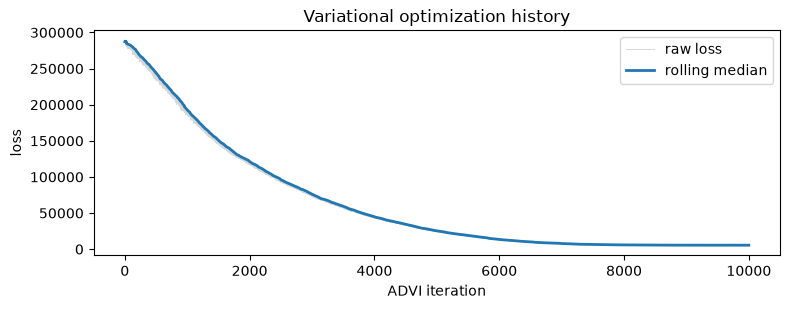

In [11]:
vi_loss = np.asarray(joint_model.vi_approx.hist, dtype=float)
rolling_loss = pd.Series(vi_loss).rolling(100, min_periods=1).median()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(vi_loss, color="0.75", lw=0.7, alpha=0.6, label="raw loss")
ax.plot(rolling_loss, color="tab:blue", lw=2, label="rolling median")
ax.set_xlabel("ADVI iteration")
ax.set_ylabel("loss")
ax.set_title("Variational optimization history")
ax.legend()
fig.tight_layout()
plt.show()

In [12]:
vi_diagnostics = pd.DataFrame(
    [
        {
            "iterations_completed": int(vi_loss.size),
            "all_finite": bool(np.isfinite(vi_loss).all()),
            "final_loss": float(vi_loss[-1]),
            "final_rolling_loss": float(rolling_loss.iloc[-1]),
            "approximate_posterior_draws": N_POSTERIOR_DRAWS,
        }
    ]
)
vi_diagnostics

,iterations_completed,all_finite,final_loss,final_rolling_loss,approximate_posterior_draws
0,10000,True,5463.503125,5463.716493,1000


,population_median,population_hdi_3%,population_hdi_97%,participant_mean_min,participant_mean_max
parameter,,,,,
rl_alpha,0.896,0.886,0.904,0.700,0.989
epsilon,0.160,0.154,0.167,0.073,0.464
scaler,0.339,0.333,0.344,0.141,0.603
A,0.177,0.173,0.180,0.072,0.219
B,0.032,0.031,0.034,0.001,0.025


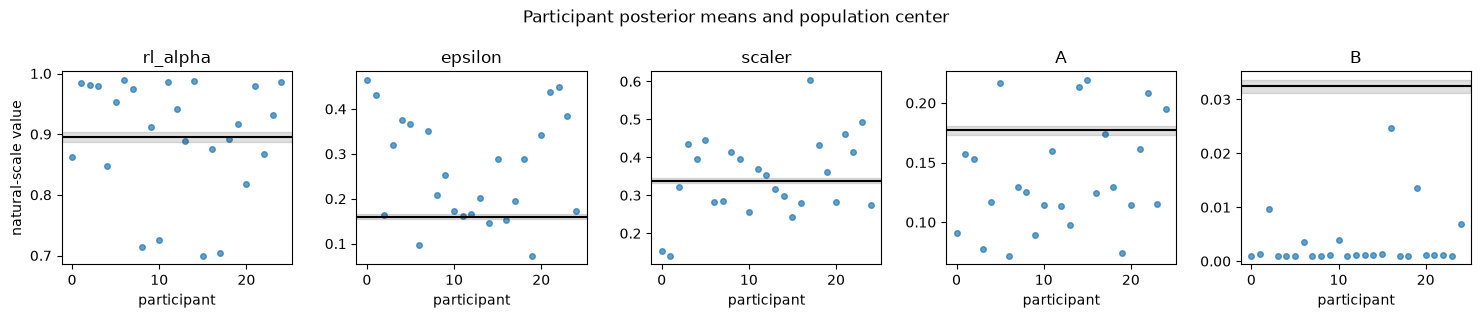

In [13]:
parameter_summary, participant_parameter_draws = extract_parameter_summary(idata)
display(parameter_summary.round(3))
plot_parameter_summary(parameter_summary, participant_parameter_draws)
plt.show()

## 7. Joint posterior predictive checks

The PPC uses causal **observed-history** replay. For each trial it
computes pre-update Q-values, simulates a joint choice and RT, and
then advances learning with the participant's observed choice and
feedback. Simulated outcomes never leak into later latent states.

Train and held-out panels use participant-level approximate posterior
draws learned from training data. Every held-out episode begins at
`INITIAL_Q`, matching its `episode_start=1` boundary.

The top row shows the posterior predictive probability of reproducing
the observed choice. The middle and bottom rows compare RT trajectories
and RT quantiles only on rows admitted by the RT mask.

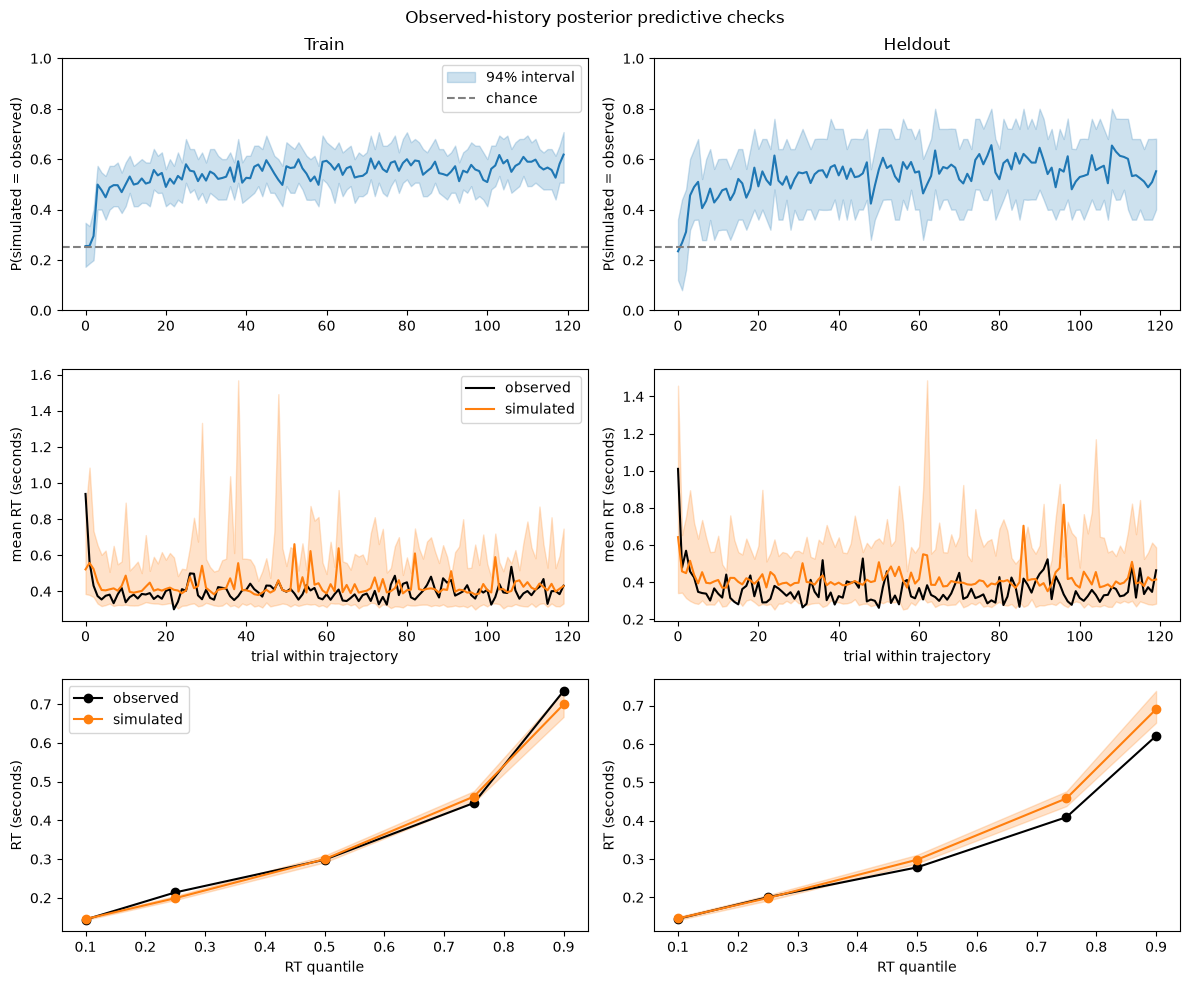

In [14]:
joint_ppc = build_joint_ppc(
    idata,
    train,
    heldout,
    subjects,
    n_draws=N_PPC_DRAWS,
)
plot_joint_ppc(joint_ppc)
plt.show()

## 8. What to remember

1. The joint notebook uses exactly the same participant/trajectory
   dataframes as the choice-only tutorial; it adds RT and mask columns.
2. `SimpleRescorlaWagnerLBA4` emits pre-update drift means and updates
   Q-values only after the current prediction.
3. `rl.ModelConfig` owns the cognitive composition;
   `RLSSMConfig.from_ssms_model` is the bridge into HSSM.
4. Hierarchical `hssm.Param` formulas express participant variation
   without changing the chronological RL mechanism.
5. `joint_model.vi(...)` returns approximate posterior draws. Its loss
   history and joint PPCs must be inspected together.
6. The RT mask defines a pragmatic first-pass pseudo-likelihood:
   excluded rows still shape later learning, but their current choice
   and RT are not directly fitted.